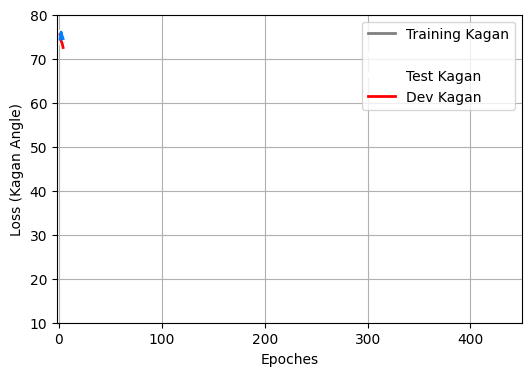

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


train_loss = np.loadtxt('train_loss.txt')
test_loss = np.loadtxt('test_loss.txt')
dev_loss = np.loadtxt('dev_loss.txt')

train_x = np.arange(1, 300*488+1)/488 # define it based on your need
test_x = np.arange(1, len(test_loss)+1)


fig = plt.figure(figsize=(6, 4))
plt.plot(train_x, train_loss[:, 2], color = [0.5, 0.5, 0.5], linewidth=2)
plt.plot(test_x, test_loss[:, 1], color = [1, 1, 1], linewidth=4)
plt.plot(test_x, dev_loss[:, 1], color = [1, 1, 1], linewidth=4)
plt.plot(test_x, test_loss[:, 1], color = [1, 0, 0], linewidth=2)
plt.plot(test_x, dev_loss[:, 1], color = [0, 0.5, 1], linewidth=2)
plt.grid()
plt.ylim([10, 80])
plt.xlim(-2, 450)
plt.xlabel('Epoches')
plt.ylabel('Loss (Kagan Angle)')
plt.legend(['Training Kagan', '', 'Test Kagan', 'Dev Kagan'])
plt.savefig('loss.pdf')

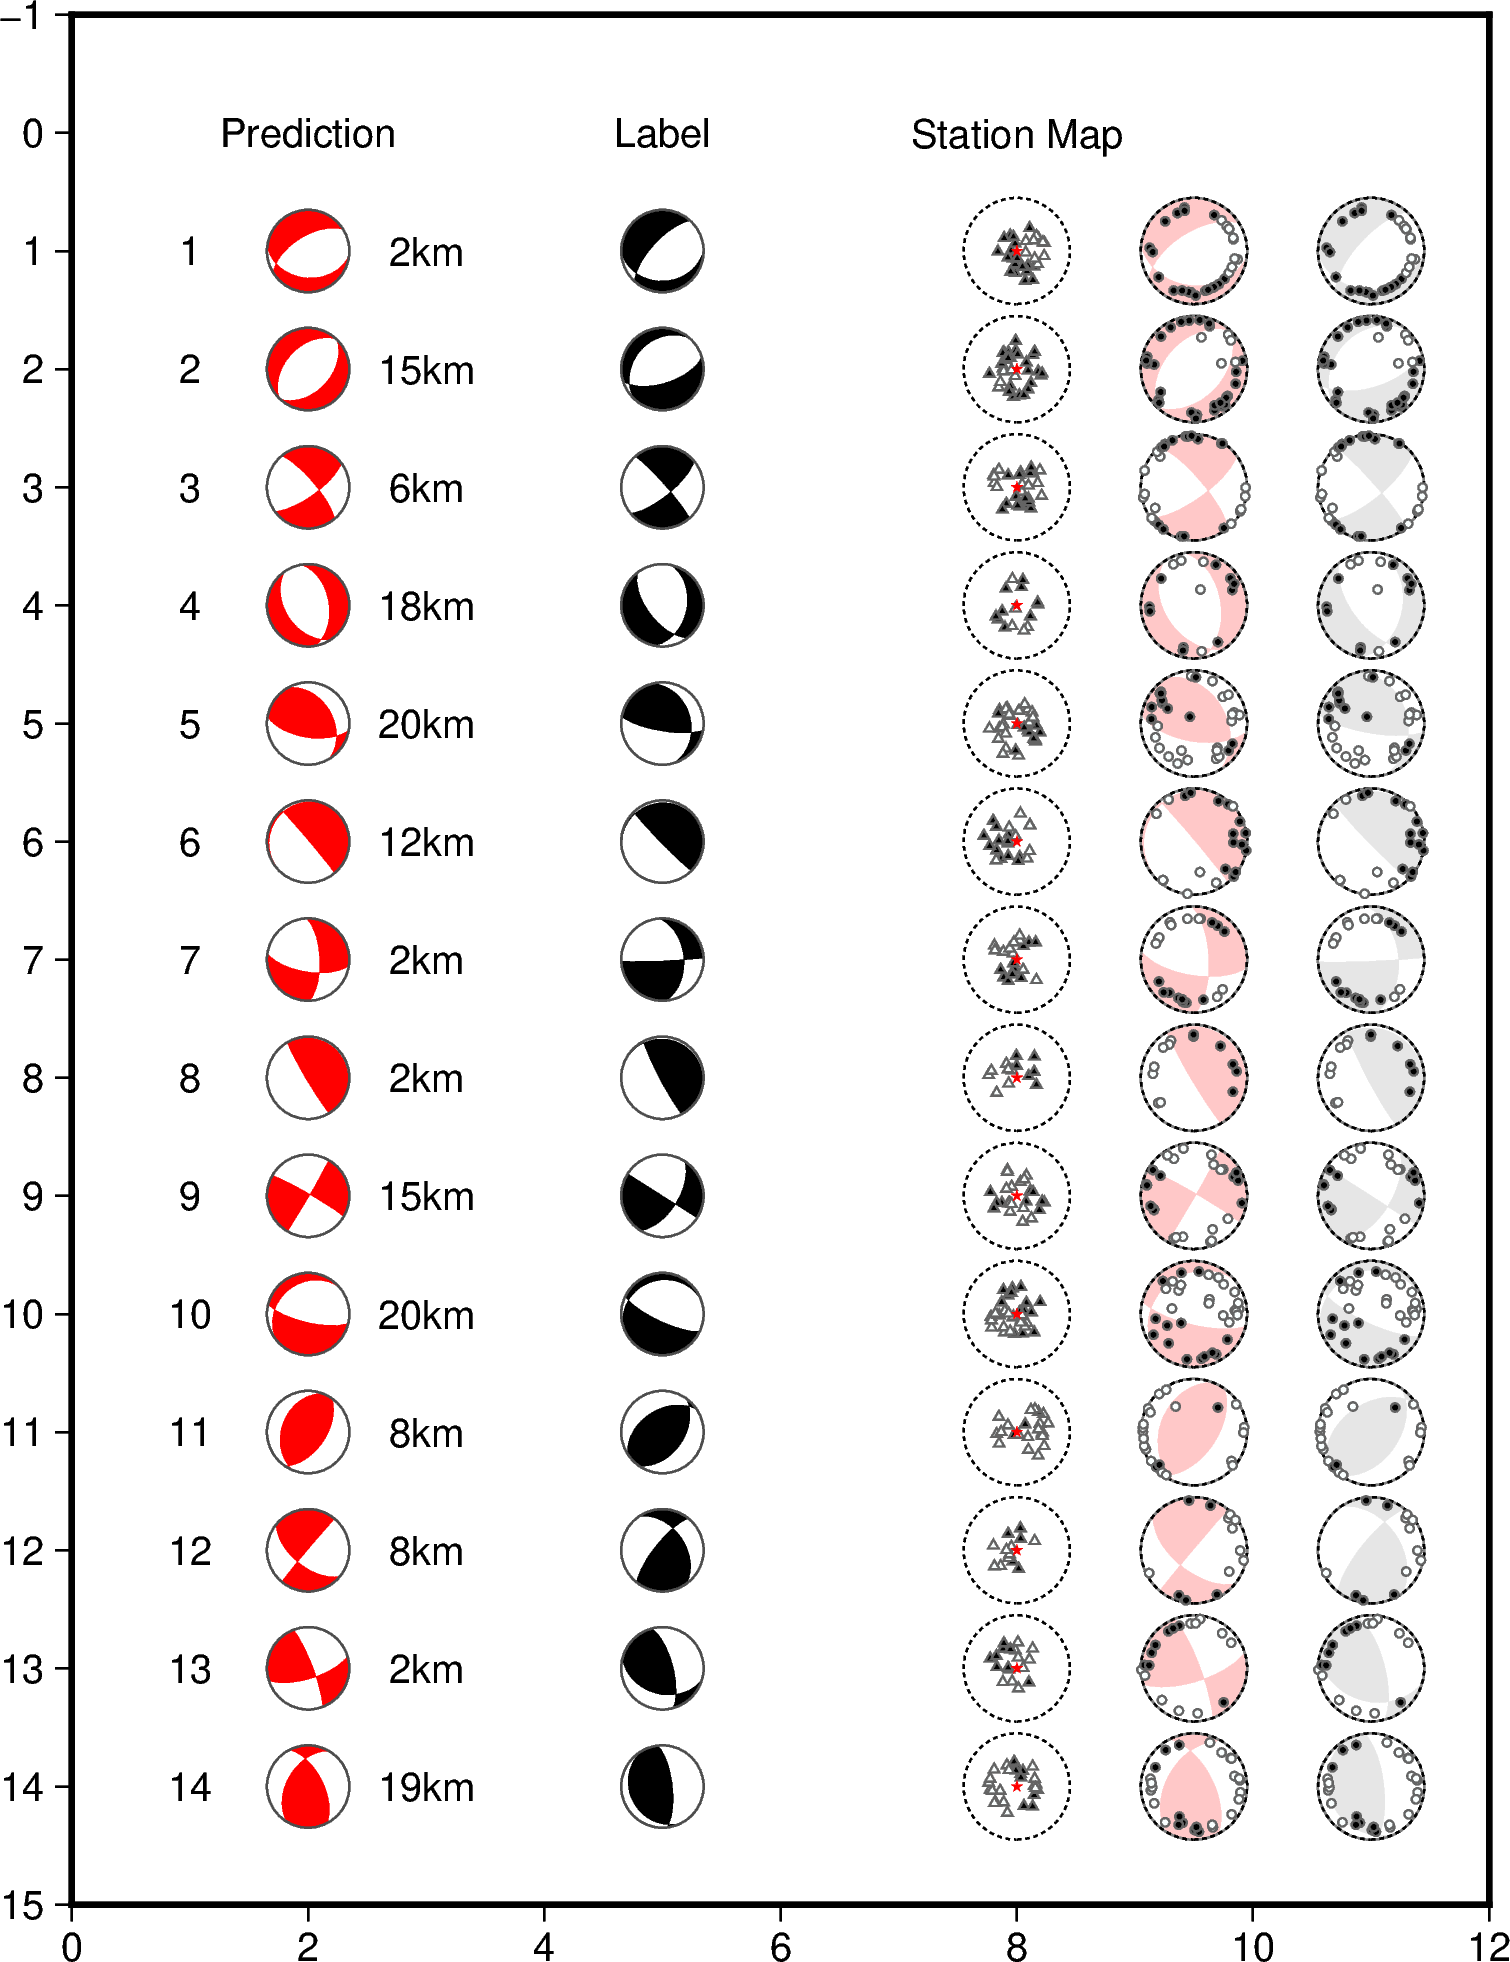

In [12]:
import pygmt as gmt
import numpy as np
from pyrocko import moment_tensor as pmt
from obspy.taup import TauPyModel
from obspy.taup import taup_create
from obspy.geodetics import gps2dist_azimuth, kilometer2degrees
from obspy.taup import TauPyModel

model = TauPyModel(model='Italian_model.npz')

# import Kagan

PTs = np.load('test_outputs.npy')
PTs = PTs.reshape(-1, 3, 3)
PTs_rf = np.load('test_referece.npy')
PTs_rf = PTs_rf.reshape(-1, 2, 3)

data_pol = np.load('Test/Test_set.npy', allow_pickle=True).item()
eids = list(data_pol.keys())

# check = (torch.exp(Kagan.PTB2Kagan(torch.Tensor(PTs_rf), torch.Tensor(PTs)))-1).sum()/64

N = PTs.shape[0]

start = 75

lst = list(range(14))

fig = gmt.Figure()
region = [0, 12, -1, 15]
fig.basemap(region=region, projection="X12c/-16c", frame=["SWrt", "xa2", "ya1"])

for i in range(len(lst)):

    ifc = lst[i]+start

    PT = PTs[ifc]
    P = PT[0, :]
    T = PT[1, :]
    moment = pmt.MomentTensor(p_axis=P, t_axis=T)
    strike, dip, rake = moment.both_strike_dip_rake()[1]
    focal_mechanism = dict(strike=strike, dip=dip, rake=rake, magnitude=5)
    fig.meca(
        spec=focal_mechanism,
        scale="0.7c",  # in centimeters
        longitude=2,
        latitude=(i+1),
        depth=10.0,
        compressionfill='red',
        pen="0.5p,gray30,solid",)
    
    PT = PTs_rf[ifc]
    P = PT[0, :]
    T = PT[1, :]
    moment = pmt.MomentTensor(p_axis=P, t_axis=T)
    strike0, dip0, rake0 = moment.both_strike_dip_rake()[1]
    focal_mechanism0 = dict(strike=strike0, dip=dip0, rake=rake0, magnitude=5)
    fig.meca(
        spec=focal_mechanism0,
        scale="0.7c",  # in centimeters
        longitude=5,
        latitude=(i+1),
        depth=10.0,
        compressionfill='black',
        pen="0.5p,gray30,solid",)
    
    stations = data_pol[eids[ifc]]['stationxyz'].astype(float)
    polarities = data_pol[eids[ifc]]['polarities']

    Xs = stations[:, 1]
    Ys = stations[:, 2]
    Azs = np.arctan2(Xs, Ys)
    Rs = np.sqrt(Xs ** 2 + Ys ** 2)
    evdp = stations[0, 3]

    Xps = []
    Yps = []

    for j in range(len(Xs)):
        path = model.get_ray_paths(source_depth_in_km=evdp, distance_in_degree=kilometer2degrees(Rs[j]), phase_list=['P','p'])
        dx = (path[0].path[1][2] - path[0].path[0][2])*6371
        dy = -(path[0].path[1][3] - path[0].path[0][3])
        take_off = np.arctan2(dx, dy)
        if abs(take_off) < 0.5*np.pi:
            take_off = -take_off
        else:
            take_off = np.pi - take_off

        nx = 1*(take_off)/(0.5*np.pi)*np.sin(Azs[j])
        ny = 1*(take_off)/(0.5*np.pi)*np.cos(Azs[j])

        Xps.append(nx)
        Yps.append(ny)
    
    Xps = np.array(Xps)
    Yps = np.array(Yps)

    fig.plot(x = 0.45*np.sin(np.arange(360)*np.pi/180)+8, y = 0.45*np.cos(np.arange(360)*np.pi/180)+i+1, pen='0.5p,1p_1p')
    fig.plot(x = Xs/300*0.9+8, y=-Ys/300*0.9+i+1, fill=-polarities[:len(Xs), 0], style='t0.1c', cmap='ocean', pen='0.4p,100')
    fig.plot(x = 8, y = i+1, style='a0.1c', fill='red')
    fig.text(x = 1, y = i+1, text=str(i+1))
    fig.text(x = 3, y = i+1, text=str(round(evdp))+'km')

    fig.meca(
        spec=focal_mechanism,
        scale="0.9c",  # in centimeters
        longitude=9.5,
        latitude=(i+1),
        depth=10.0,
        compressionfill='255/200/200',
        pen="0.5p,gray50,solid",
        transparency=0)
    fig.plot(x = 0.45*np.sin(np.arange(360)*np.pi/180)+9.5, y = 0.45*np.cos(np.arange(360)*np.pi/180)+i+1, pen='0.5p,0,1p_1p')
    fig.plot(x = Xps*0.45+9.5, y=-Yps*0.45+i+1, fill=-polarities[:len(Xps), 0], style='c0.07c', pen='0.4p,100', cmap='ocean')

    fig.meca(
        spec=focal_mechanism0,
        scale="0.9c",  # in centimeters
        longitude=11,
        latitude=(i+1),
        depth=10.0,
        compressionfill='230',
        pen="0.5p,gray50,solid",
        transparency=0)
    fig.plot(x = 0.45*np.sin(np.arange(360)*np.pi/180)+11, y = 0.45*np.cos(np.arange(360)*np.pi/180)+i+1, pen='0.5p,0,1p_1p')
    fig.plot(x = Xps*0.45+11, y=-Yps*0.45+i+1, fill=-polarities[:len(Xps), 0], style='c0.07c', pen='0.4p,100', cmap='ocean')


fig.text(x=2, y=0, text='Prediction')
fig.text(x=5, y=0, text='Label')
fig.text(x=8, y=0, text='Station Map')

fig.show()
fig.savefig('result.pdf')



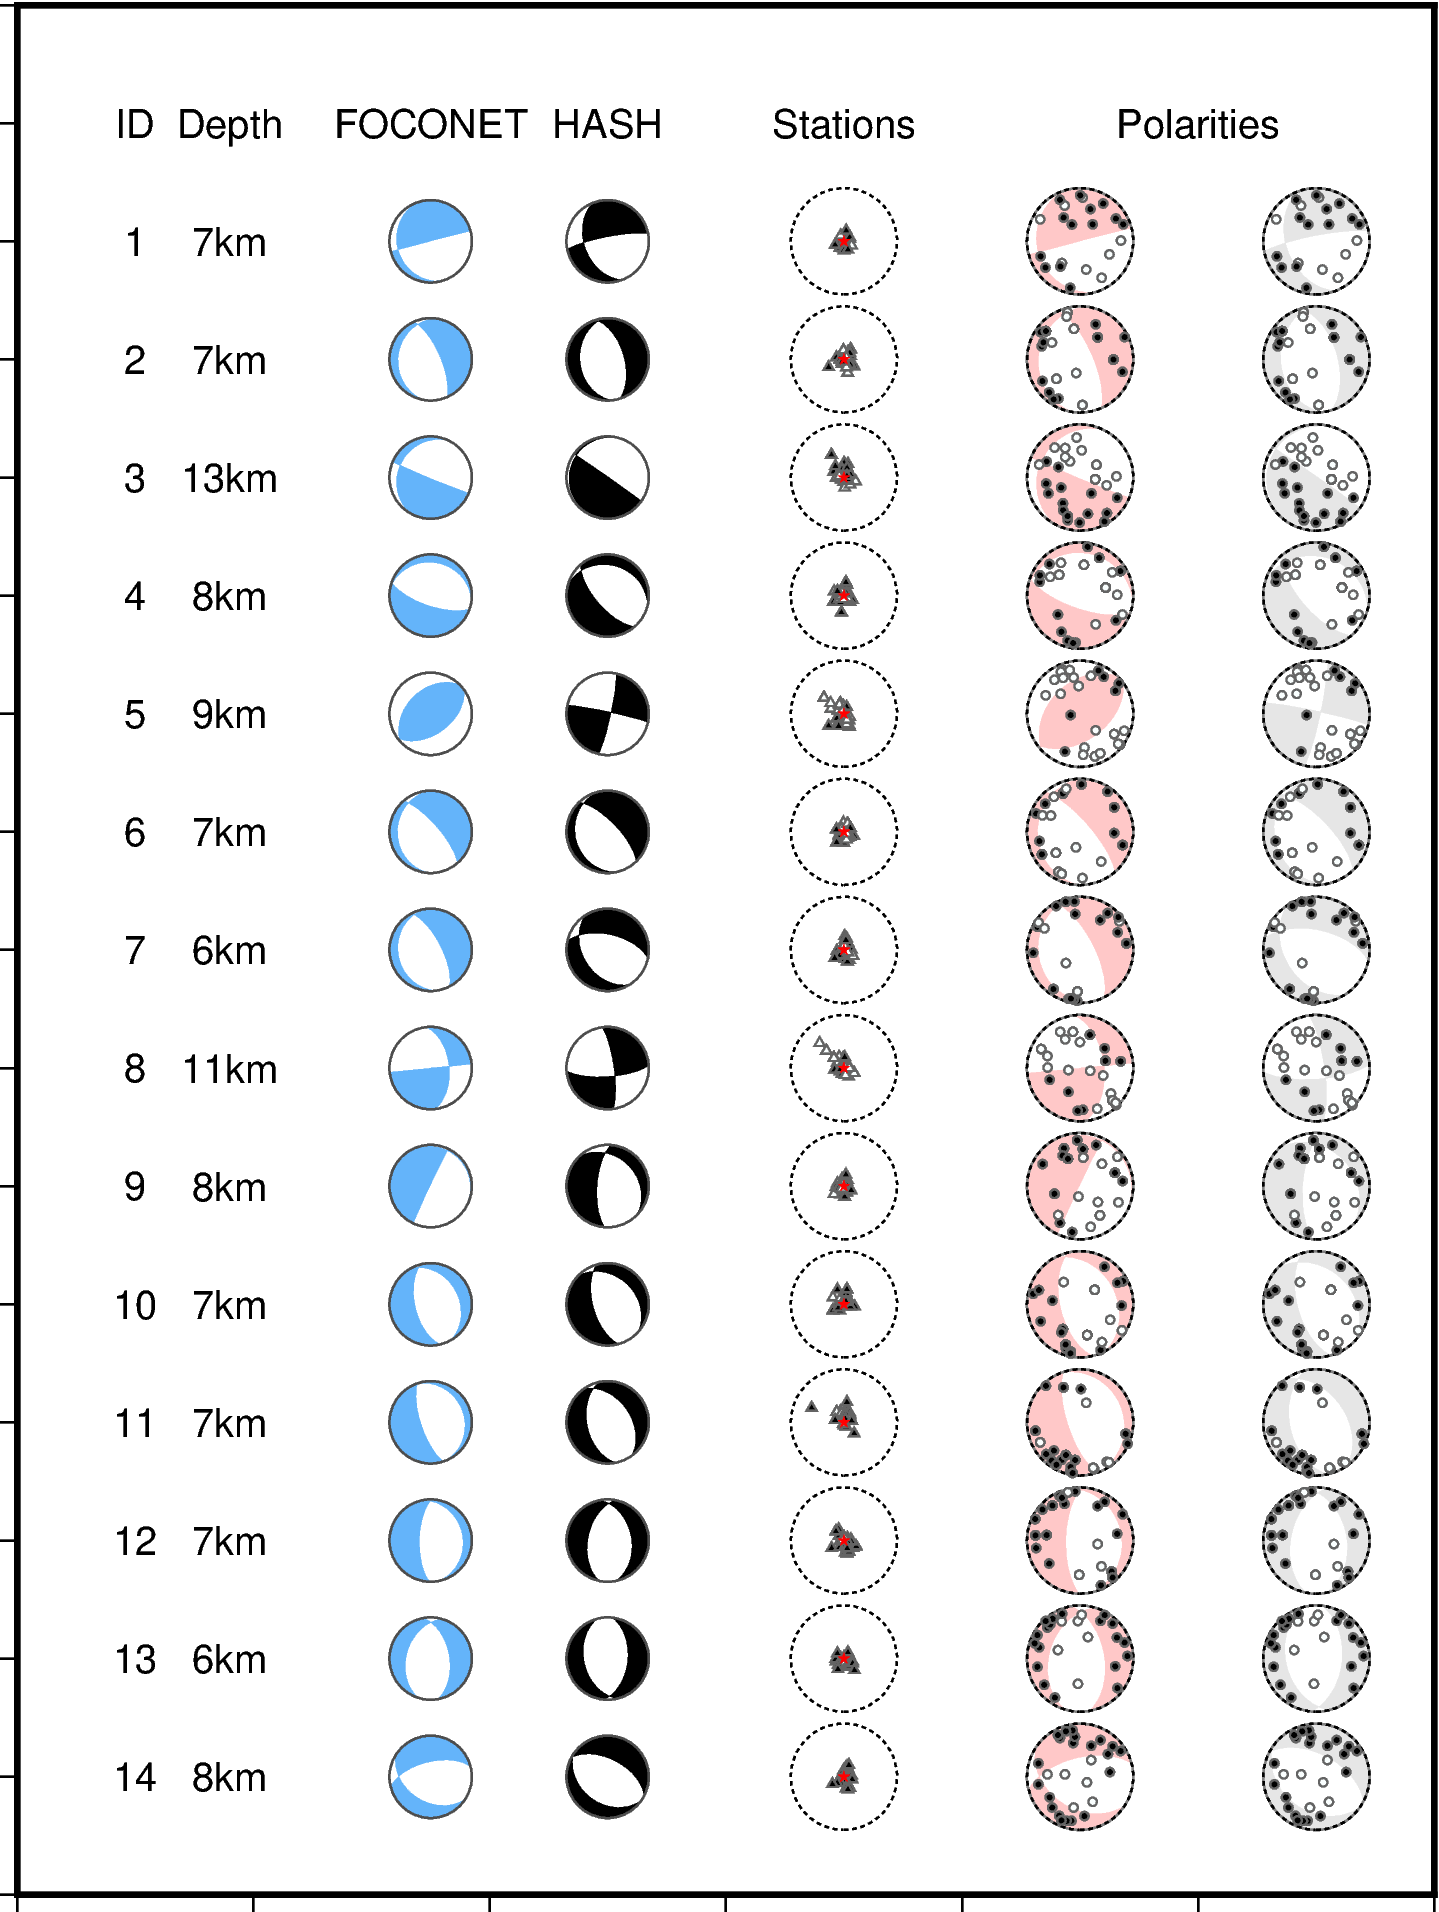

In [7]:
import pygmt as gmt
import numpy as np
from pyrocko import moment_tensor as pmt
from obspy.taup import TauPyModel
from obspy.taup import taup_create
from obspy.geodetics import gps2dist_azimuth, kilometer2degrees
from obspy.taup import TauPyModel

model = TauPyModel(model='Italian_model.npz')

# import Kagan

PTs = np.load('dev_outputs.npy')
PTs = PTs.reshape(-1, 3, 3)
PTs_rf = np.load('dev_referece.npy')
PTs_rf = PTs_rf.reshape(-1, 2, 3)

data_pol = np.load('Dev/Dev_set.npy', allow_pickle=True).item()
eids = list(data_pol.keys())

# check = (torch.exp(Kagan.PTB2Kagan(torch.Tensor(PTs_rf), torch.Tensor(PTs)))-1).sum()/64

N = PTs.shape[0]

start = 75

lst = list(range(14))

fig = gmt.Figure()
region = [0, 12, -1, 15]
fig.basemap(region=region, projection="X12c/-16c", frame=["wsrt", "xa2", "ya1"])

for i in range(len(lst)):

    ifc = lst[i]+start

    PT = PTs[ifc]
    P = PT[0, :]
    T = PT[1, :]
    moment = pmt.MomentTensor(p_axis=P, t_axis=T)
    strike, dip, rake = moment.both_strike_dip_rake()[1]
    focal_mechanism = dict(strike=strike, dip=dip, rake=rake, magnitude=5)
    fig.meca(
        spec=focal_mechanism,
        scale="0.7c",  # in centimeters
        longitude=3.5,
        latitude=(i+1),
        depth=10.0,
        compressionfill='100/180/250',
        pen="0.5p,gray30,solid",)
    
    PT = PTs_rf[ifc]
    P = PT[0, :]
    T = PT[1, :]
    moment = pmt.MomentTensor(p_axis=P, t_axis=T)
    strike0, dip0, rake0 = moment.both_strike_dip_rake()[1]
    focal_mechanism0 = dict(strike=strike0, dip=dip0, rake=rake0, magnitude=5)
    fig.meca(
        spec=focal_mechanism0,
        scale="0.7c",  # in centimeters
        longitude=5,
        latitude=(i+1),
        depth=10.0,
        compressionfill='black',
        pen="0.5p,gray30,solid",)
    
    stations = data_pol[eids[ifc]]['stationxyz'][:, 1:].astype(float)
    polarities = data_pol[eids[ifc]]['polarities']

    Xs = stations[:, 0]
    Ys = stations[:, 1]
    Azs = np.arctan2(Xs, Ys)
    Rs = np.sqrt(Xs ** 2 + Ys ** 2)
    evdp = stations[0, 2]

    Xps = []
    Yps = []

    for j in range(len(Xs)):
        path = model.get_ray_paths(source_depth_in_km=evdp, distance_in_degree=kilometer2degrees(Rs[j]), phase_list=['P','p'])
        dx = (path[0].path[1][2] - path[0].path[0][2])*6371
        dy = -(path[0].path[1][3] - path[0].path[0][3])
        take_off = np.arctan2(dx, dy)
        if abs(take_off) < 0.5*np.pi:
            take_off = -take_off
        else:
            take_off = np.pi - take_off

        nx = 1*(take_off)/(0.5*np.pi)*np.sin(Azs[j])
        ny = 1*(take_off)/(0.5*np.pi)*np.cos(Azs[j])

        Xps.append(nx)
        Yps.append(ny)
    
    Xps = np.array(Xps)
    Yps = np.array(Yps)

    fig.plot(x = 0.45*np.sin(np.arange(360)*np.pi/180)+7, y = 0.45*np.cos(np.arange(360)*np.pi/180)+i+1, pen='0.5p,1p_1p')
    fig.plot(x = Xs/300*0.9+7, y=-Ys/300*0.9+i+1, fill=-polarities[:len(Xs), 0], style='t0.1c', cmap='ocean', pen='0.4p,100')
    fig.plot(x = 7, y = i+1, style='a0.1c', fill='red')
    fig.text(x = 1, y = i+1, text=str(i+1))
    fig.text(x = 1.8, y = i+1, text=str(round(evdp))+'km')

    fig.meca(
        spec=focal_mechanism,
        scale="0.9c",  # in centimeters
        longitude=9,
        latitude=(i+1),
        depth=10.0,
        compressionfill='255/200/200',
        pen="0.5p,gray50,solid",
        transparency=0)
    fig.plot(x = 0.45*np.sin(np.arange(360)*np.pi/180)+9, y = 0.45*np.cos(np.arange(360)*np.pi/180)+i+1, pen='0.5p,0,1p_1p')
    fig.plot(x = Xps*0.45+9, y=-Yps*0.45+i+1, fill=-polarities[:len(Xps), 0], style='c0.07c', pen='0.4p,100', cmap='ocean')

    fig.meca(
        spec=focal_mechanism0,
        scale="0.9c",  # in centimeters
        longitude=11,
        latitude=(i+1),
        depth=10.0,
        compressionfill='230',
        pen="0.5p,gray50,solid",
        transparency=0)
    fig.plot(x = 0.45*np.sin(np.arange(360)*np.pi/180)+11, y = 0.45*np.cos(np.arange(360)*np.pi/180)+i+1, pen='0.5p,0,1p_1p')
    fig.plot(x = Xps*0.45+11, y=-Yps*0.45+i+1, fill=-polarities[:len(Xps), 0], style='c0.07c', pen='0.4p,100', cmap='ocean')

fig.text(x=1, y=0, text='ID')
fig.text(x=1.8, y=0, text='Depth')
fig.text(x=3.5, y=0, text='FOCONET')
fig.text(x=5, y=0, text='HASH')
fig.text(x=7, y=0, text='Stations')
fig.text(x=10, y=0, text='Polarities')

fig.show()
fig.savefig('dev_result.pdf')



station number: 32


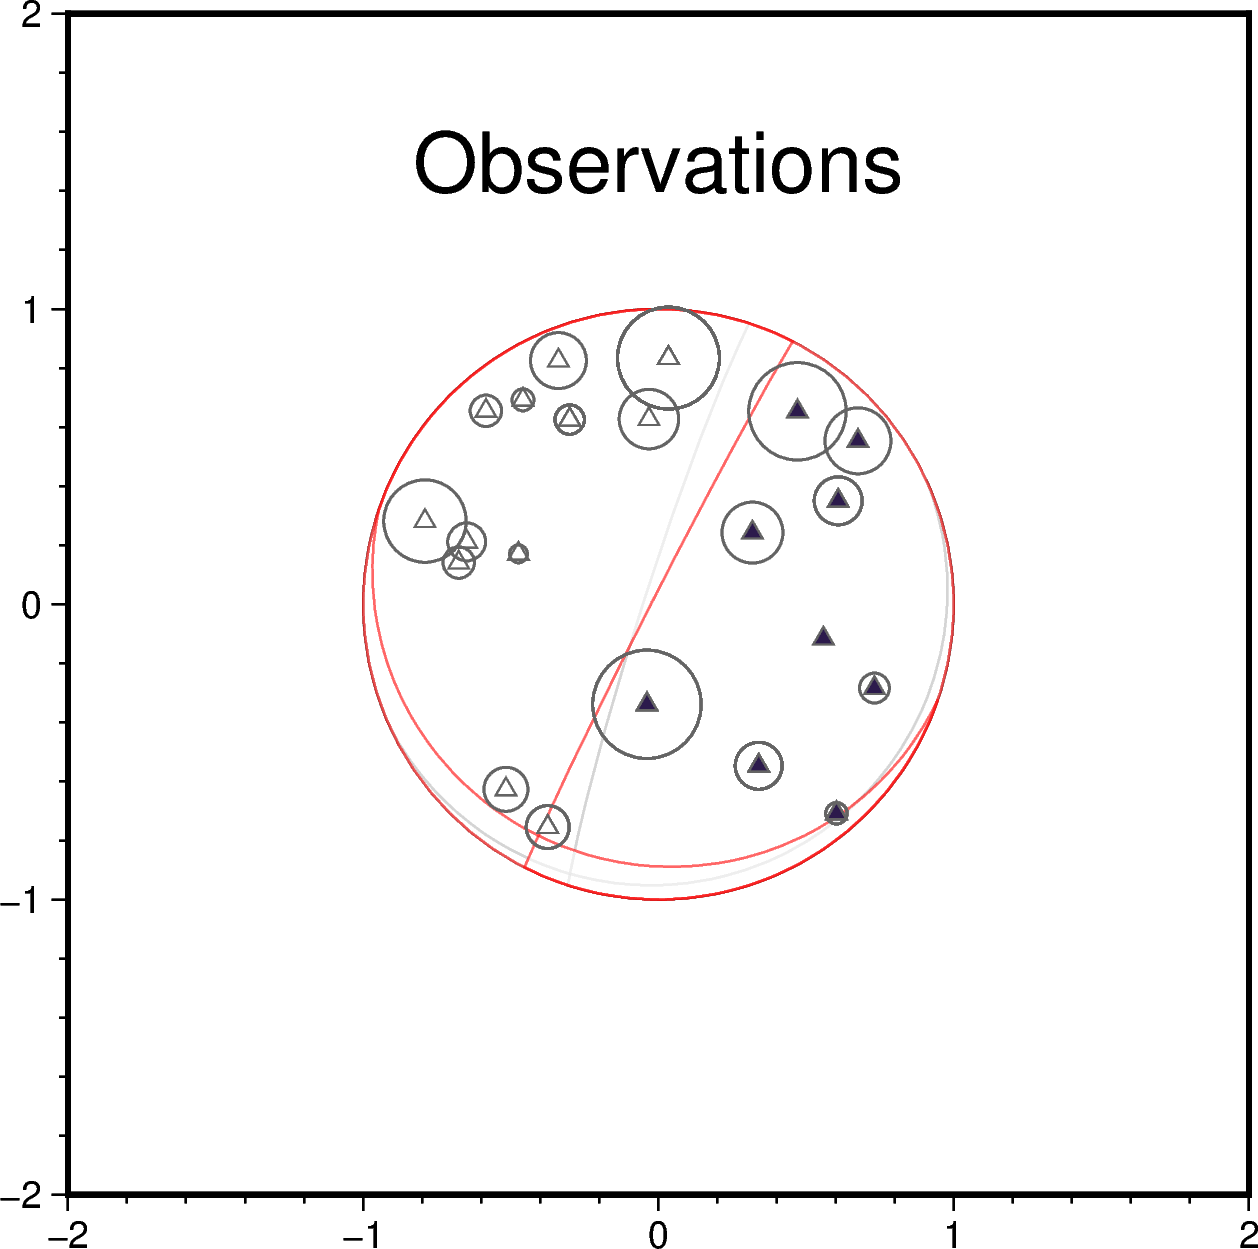

In [15]:
data_pol = np.load('Dev/Dev_set.npy', allow_pickle=True).item()
PTs = np.load('dev_outputs.npy')
PTs = PTs.reshape(-1, 3, 3)

eids = list(data_pol.keys())

idx = 18
eid = eids[idx]

focmec0 = data_pol[eid]['focalmech']
stationxyz = data_pol[eid]['stationxyz']
pol_data = data_pol[eid]['polarities']
strike0, dip0, rake0 = focmec0
evdp = float(stationxyz[0, -1])

PT = PTs[idx]
P = PT[0, :]
T = PT[1, :]
moment = pmt.MomentTensor(p_axis=P, t_axis=T)
strike, dip, rake = moment.both_strike_dip_rake()[1]

stations = stationxyz[:, 1:].astype(float)
print('station number:', len(stationxyz[:, 0]))

Xs = stations[:, 0]
Ys = stations[:, 1]
Azs = np.arctan2(Xs, Ys)
Rs = np.sqrt(Xs ** 2 + Ys ** 2)

Xps = []
Yps = []
polarities = []
srps = []

for j in range(len(Xs)):
    path = model.get_ray_paths(source_depth_in_km=evdp, distance_in_degree=kilometer2degrees(Rs[j]), phase_list=['p','P'])
    dx = (path[0].path[1][2] - path[0].path[0][2])*6371
    dy = -(path[0].path[1][3] - path[0].path[0][3])
    take_off = np.arctan2(dx, dy)
    if abs(take_off) < 0.5*np.pi:
        take_off = -take_off
    else:
        take_off = np.pi - take_off

    nx = 1*(take_off)/(0.5*np.pi)*np.sin(Azs[j])
    ny = 1*(take_off)/(0.5*np.pi)*np.cos(Azs[j])

    Xps.append(nx)
    Yps.append(ny)

    pol = pol_data[j, 0]
    SrP = pol_data[j, 7]

    polarities.append(pol)
    srps.append(SrP)

polarities = np.array(polarities)
srps = np.array(srps)

Xps = np.array(Xps)
Yps = np.array(Yps)

fig = gmt.Figure()
focal_mechanism = dict(strike=strike, dip=dip, rake=rake, magnitude=5)
focal_mechanism0 = dict(strike=strike0, dip=dip0, rake=rake0, magnitude=5)
region = [-2, 2, -2, 2]
fig.basemap(region=region, projection="X10c/10c", frame=True)

fig.meca(spec=focal_mechanism0,scale="5c",longitude=0,latitude=0,depth=10.0,compressionfill="white",pen="0.5p,gray30,solid",outline="0.5p,gray30,solid", transparency=40)
fig.meca(spec=focal_mechanism,scale="5c",longitude=0,latitude=0,depth=10.0,compressionfill="white",pen="0.5p,gray30,solid", outline="0.5p,red,solid", transparency=40)

fig.plot(x = Xps, y=Yps, fill=polarities[:len(Xps)], style='t0.2c', pen='0.4p,100', cmap='devon')
fig.plot(x = Xps, y=Yps, size = np.clip(srps, 0, 10)*0.25, style='c', pen='0.6p,100')

fig.text(x = 0, y = 1.5, text = 'Observations', font='20p')

fig.savefig('focal.pdf')
fig.show()
